# Information Retrieval and Summarization on Multiple Users Meeting


In [93]:
import random
from datasets import load_dataset, Audio
from huggingface_hub import constants
import torchaudio
import torch
import torch.nn.functional as F
import os, json, io
from sklearn.cluster import AgglomerativeClustering, SpectralClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.linalg import eigh
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
from nemo.collections.asr.models import EncDecSpeakerLabelModel
from tqdm import tqdm
from transformers import WavLMModel
from whisper.model import Whisper
import whisper
import warnings
warnings.filterwarnings("ignore", module="whisper.timing")
import umap
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

import soundfile as sf
from silero_vad import (
    load_silero_vad,
    read_audio,
    get_speech_timestamps,
    save_audio,
    VADIterator,
    collect_chunks,
)
from typing import Tuple, List, Dict
from speechbrain.utils.fetching import LocalStrategy
from speechbrain.inference import EncoderClassifier
import numpy as np
from rsmm_utils import (
    # dump_dataset_paths,
    # load_audio,
    # is_titanet,
    ensure_mono,
    pad_or_trim,
    segments_to_frames,
    expand_segments_to_frames,
    group_runs,
    extract_frame_errors,
    normalize_labels,
)
from embd_speech_seg import (
    extract_embeddings_from_segments,
    extract_wavlm_embeddings_from_segments,
)
import dotenv
import groq
from groq import Groq
import json

In [17]:
DATASET_DIR = "audio_out"

In [18]:
def eval_detection(detected, ground_truth, tolerance=0.01):
    """
    Evaluate speech activity detection (VAD) similar to DER
    but only for speech/silence (no speaker labels).

    Parameters
    ----------
    detected : list of (start, end) in seconds
        Predicted speech segments.
    ground_truth : list of (start, end) in seconds
        Reference speech segments.
    tolerance : float, optional
        Extra margin (in seconds) to allow small misalignments.

    Returns
    -------
    recall : float
        Proportion of ground-truth speech time correctly detected.
    fa_rate : float
        Proportion of detected speech time that is false alarm (not in GT).
    """

    # Flatten into frame-level timeline with step resolution
    # (here 10ms frames, similar to pyannote)
    frame_hop = 0.01
    if not ground_truth or not detected:
        return 0.0, 0.0

    # Find total duration
    max_time = max(
        max(e for _, e in ground_truth),
        max(e for _, e in detected)
    )

    n_frames = int(max_time / frame_hop) + 1
    gt_activity = [0] * n_frames
    det_activity = [0] * n_frames

    # Mark GT frames
    for s, e in ground_truth:
        s_i = int((s - tolerance) / frame_hop)
        e_i = int((e + tolerance) / frame_hop)
        for i in range(max(0, s_i), min(n_frames, e_i)):
            gt_activity[i] = 1

    # Mark detected frames
    for s, e in detected:
        s_i = int((s - tolerance) / frame_hop)
        e_i = int((e + tolerance) / frame_hop)
        for i in range(max(0, s_i), min(n_frames, e_i)):
            det_activity[i] = 1

    # Compute overlaps
    tp = sum(1 for g, d in zip(gt_activity, det_activity) if g == 1 and d == 1)
    fn = sum(1 for g, d in zip(gt_activity, det_activity) if g == 1 and d == 0)
    fp = sum(1 for g, d in zip(gt_activity, det_activity) if g == 0 and d == 1)

    print("True Pos, False Neg, False Pos", tp, fn, fp)
    recall = tp / (tp + fn + 1e-9)
    fa_rate = fp / (tp + fp + 1e-9)

    return recall, fa_rate


### Clustering

In [19]:
def spectral_cluster_eigengap(embeddings, min_clusters=2, max_clusters=20):
    """
    Spectral clustering with cluster count determined by the eigen-gap heuristic.
    
    Parameters
    ----------
    embeddings : array-like, shape (n_samples, n_features)
        Speaker embeddings.
    min_clusters : int, default=2
        Minimum number of clusters to consider.
    max_clusters : int, default=20
        Maximum number of clusters to consider.
    
    Returns
    -------
    labels : ndarray, shape (n_samples,)
        Cluster labels assigned to each embedding.
    k_opt : int
        Estimated optimal number of clusters (from eigen-gap).
    eigvals : ndarray
        Sorted eigenvalues of the Laplacian.
    gaps : ndarray
        Differences between consecutive eigenvalues.
    """

    # Step 1: similarity (cosine)
    sim = cosine_similarity(embeddings)
    
    # Step 2: degree matrix
    degrees = sim.sum(axis=1)
    D = np.diag(degrees)
    
    # Step 3: normalized Laplacian
    with np.errstate(divide='ignore'):
        D_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(degrees, 1e-12)))
    L = np.eye(len(sim)) - D_inv_sqrt @ sim @ D_inv_sqrt

    # Step 4: eigen decomposition
    eigvals, _ = eigh(L)
    eigvals = np.sort(eigvals)[:max_clusters+1]

    # Step 5: eigen-gap
    gaps = np.diff(eigvals)
    search_region = gaps[min_clusters-1:max_clusters-1]
    best_idx = np.argmax(search_region)
    k_opt = best_idx + min_clusters

    # Step 6: spectral clustering with k_opt
    clustering = SpectralClustering(
        n_clusters=k_opt,
        affinity="nearest_neighbors",
        assign_labels="kmeans",
        random_state=0
    ).fit(embeddings)

    return clustering.labels_, k_opt, eigvals, gaps



def agglomerative_k_search(
    embeddings: np.ndarray,
    metric: str = "cosine",
    linkage_method: str = "average",
    min_clusters: int = 2,
    max_clusters: int = 20,
):
    """
    Cluster embeddings with Agglomerative (dendrogram once, cut by k).
    Picks best k in [min_clusters, max_clusters] using silhouette score.

    Returns:
        best_labels: np.ndarray of shape (N,)
        best_k: int, chosen number of clusters
        best_score: float
        Z: linkage matrix
    """
    n_samples = embeddings.shape[0]
    if n_samples < 2:
        return np.zeros(n_samples, dtype=int), 1, 0.0, None

    # Step 1: compute pairwise distances and dendrogram (once)
    condensed = pdist(embeddings, metric=metric)
    Z = linkage(condensed, method=linkage_method)

    # Step 2: cache full distance matrix for silhouette
    dist_mat = squareform(condensed)

    best_score = -np.inf
    best_labels, best_k = None, None

    # Step 3: sweep possible k values
    for k in range(min_clusters, min(max_clusters, n_samples - 1) + 1):
        labels = fcluster(Z, t=k, criterion="maxclust")
        n_clusters = len(set(labels))
        if n_clusters < 2:
            continue

        try:
            score = silhouette_score(dist_mat, labels, metric="precomputed")
        except Exception:
            score = -davies_bouldin_score(embeddings, labels)

        if score > best_score:
            best_score = score
            best_labels = labels
            best_k = n_clusters

    # Fallback: if nothing valid, just cut at min_clusters
    if best_labels is None:
        best_labels = fcluster(Z, t=min_clusters, criterion="maxclust")
        best_k = min_clusters
        try:
            best_score = silhouette_score(dist_mat, best_labels, metric="precomputed")
        except Exception:
            best_score = -davies_bouldin_score(embeddings, best_labels)

    return best_labels, best_k, best_score


In [20]:
def umap_cluster_embeddings(
    embeddings,
    reducer_dim=10,
    gt_labels=None,
    n_clusters=None,
    random_state=42,
):
    """
    UMAP -> KMeans clustering.

    Returns:
      speaker_labels (list[str])   - e.g. ["SPEAKER_00", ...] (compatible with your pipeline)
      cluster_ids (ndarray[int])   - raw numeric cluster ids from KMeans
      emb_reduced (ndarray)        - UMAP-reduced embeddings (n x reducer_dim)
      label2id (dict)              - map from string label -> numeric id (for plotting)
      results (dict)               - metrics and extra info
    """
    # 1) UMAP reduction
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=reducer_dim,
        metric="cosine",
        random_state=random_state,
    )
    emb_reduced = reducer.fit_transform(embeddings)

    print(len(set(gt_labels)))
    # 2) cluster count
    if n_clusters is None:
        if gt_labels is not None:
            n_clusters = len(set(gt_labels))
        else:
            raise ValueError("Need n_clusters or gt_labels to infer cluster count")

    # 3) clustering
    km = KMeans(n_clusters=n_clusters, random_state=random_state)
    cluster_ids = km.fit_predict(emb_reduced)   # numeric 0..K-1 (but order not guaranteed)

    # 4) build stable id->label using order-of-appearance of cluster ids
    unique_clusters = list(dict.fromkeys(cluster_ids))  # preserve appearance order
    id2label = {cid: f"SPEAKER_{i:02d}" for i, cid in enumerate(unique_clusters)}
    speaker_labels = [id2label[cid] for cid in cluster_ids]

    # 5) label -> numeric id mapping (for plotting)
    unique_labels = [id2label[cid] for cid in unique_clusters]
    label2id = {label: i for i, label in enumerate(unique_labels)}
    numeric_labels = np.array([label2id[lbl] for lbl in speaker_labels], dtype=int)

    # 6) metrics (use numeric cluster_ids for ARI/NMI)
    results = {
        "umap_embeddings": emb_reduced,
        "cluster_ids": cluster_ids,
        "label2id": label2id,
        "numeric_labels": numeric_labels,
        "ari": None,
        "nmi": None,
    }
    if gt_labels is not None and len(gt_labels) == len(cluster_ids):
        results["ari"] = adjusted_rand_score(gt_labels, cluster_ids)
        results["nmi"] = normalized_mutual_info_score(gt_labels, cluster_ids)

    return speaker_labels, cluster_ids, emb_reduced, label2id, results


In [21]:
def transcribe_chunks(waveform, sr, chunks, asr_model: Whisper):
    """
    Run Whisper ASR on pre-chunked waveform segments.
    - waveform: torch.Tensor [1, num_samples]
    - sr: sample rate
    - chunks: list of dicts with {start, end, segments} in samples
    - asr_model: loaded Whisper model
    Returns transcripts aligned in **samples** (not seconds).
    """
    transcripts = []

    for i, c in tqdm(enumerate(chunks), total=len(chunks), desc="Transcribing"):
    # Slice chunk by samples
        segment = waveform[:, c["start"]:c["end"]].cpu().numpy()
        segment = segment.squeeze().astype("float32")

        # Normalize if needed
        if segment.max() > 1.0:
            segment = segment / max(1e-9, abs(segment).max())

        # Run Whisper with timestamps
        result = asr_model.transcribe(
            segment,
            fp16=False,  # safer on CPU/small GPU
            word_timestamps=True,  # return per-word timestamps
            beam_size=7,  # beam search for stability
            temperature=(0, 0.1, 0.2, 0.4, 0.8),  # deterministic output
            compression_ratio_threshold=1.8,
        )

        # Convert Whisper word timestamps (sec) → samples
        words = []
        for w in result.get("segments", []):
            for item in w["words"]:
                words.append(
                    {
                        "word": item["word"],
                        "start": c["start"] + int(item["start"] * sr),
                        "end": c["start"] + int(item["end"] * sr),
                    }
                )

        transcripts.append(
            {
                "chunk_id": i,
                "start": c["start"],  # in samples
                "end": c["end"],  # in samples
                "text": result["text"].strip(),
                "words": words,
            }
        )

        # Optional debug log in seconds
        # print(f"[Chunk {i}] {c['start']/sr:.2f}-{c['end']/sr:.2f}s: {result['text'].strip()}")
        # print(f"[Chunk {i}] {c['start']/sr:.4f}-{c['end']/sr:.4f}s", end=" ")

    return transcripts


def chunk_by_silence_and_overlap(
    speech_timestamps,
    sr,
    min_silence=2.0,
    max_chunk=30.0,
    overlap=5.0,
):
    """
    Create ASR chunks from diarization speech timestamps.
    Works in samples, not seconds.
    Ensures that overlapping windows only carry their relevant segments.
    """
    min_silence_samples = int(min_silence * sr)
    max_chunk_samples = int(max_chunk * sr)
    overlap_samples = int(overlap * sr)

    chunks = []
    cur_segments = []
    cur_start, cur_end = None, None

    # --- First pass: group by silence gaps ---
    for seg in speech_timestamps:
        start, end = (seg["start"], seg["end"]) if isinstance(seg, dict) else seg

        if cur_start is None:
            cur_start, cur_end = start, end
            cur_segments = [(start, end)]
            continue

        gap = start - cur_end

        if gap >= min_silence_samples:
            chunks.append(
                {"start": cur_start, "end": cur_end, "segments": cur_segments}
            )
            cur_start, cur_end = start, end
            cur_segments = [(start, end)]
        else:
            cur_end = end
            cur_segments.append((start, end))

    if cur_segments:
        chunks.append({"start": cur_start, "end": cur_end, "segments": cur_segments})

    # --- Second pass: split long chunks with overlap ---
    final_chunks = []
    for c in chunks:
        duration = c["end"] - c["start"]
        if duration <= max_chunk_samples:
            final_chunks.append(c)
        else:
            start = c["start"]
            while start < c["end"]:
                end = min(start + max_chunk_samples, c["end"])

                # ✅ keep only segments that intersect this sub-window
                sub_segments = [
                    (s, e)
                    for (s, e) in c["segments"]
                    if e > start and s < end
                ]

                final_chunks.append(
                    {"start": start, "end": end, "segments": sub_segments}
                )

                if end == c["end"]:
                    break
                start = end - overlap_samples  # slide with overlap

    return final_chunks


def assign_speakers(transcripts, diar_segments, sr, snap_gap_sec=1):
    snap_gap_samples = int(snap_gap_sec * sr)
    results = []
    cur_speaker, cur_words = None, []

    # flatten word-level info across chunks
    words_all = []
    for t in transcripts:
        words_all.extend(t["words"])

    for w in words_all:
        w_mid = (w["start"] + w["end"]) // 2

        # find diar segment covering this word
        candidates = [
            seg for seg in diar_segments if seg["start"] <= w_mid <= seg["end"]
        ]
        if candidates:
            speaker = candidates[0]["speaker"]
        else:
            # nearest diar segment
            nearest = min(
                diar_segments,
                key=lambda s: min(abs(w_mid - s["start"]), abs(w_mid - s["end"])),
            )
            gap = min(abs(w_mid - nearest["start"]), abs(w_mid - nearest["end"]))
            speaker = nearest["speaker"] if gap <= snap_gap_samples else None

        # group by speaker
        if speaker != cur_speaker:
            if cur_words:
                results.append(
                    {
                        "speaker": (
                            f"Speaker {cur_speaker}"
                            if isinstance(cur_speaker, (int, np.integer))
                            else (cur_speaker or "Unknown")
                        ),
                        "start": min(wd["start"] for wd in cur_words),
                        "end": max(wd["end"] for wd in cur_words),
                        "text": " ".join(wd["word"] for wd in cur_words),
                    }
                )
            cur_speaker, cur_words = speaker, [w]
        else:
            cur_words.append(w)

    # flush last
    if cur_words:
        results.append(
            {
                "speaker": (
                    f"Speaker {cur_speaker}"
                    if isinstance(cur_speaker, (int, np.integer))
                    else (cur_speaker or "Unknown")
                ),
                "start": min(wd["start"] for wd in cur_words),
                "end": max(wd["end"] for wd in cur_words),
                "text": " ".join(wd["word"] for wd in cur_words),
            }
        )

    return results


### Diarization

In [22]:
def run_vad_segmentation(waveform, vad_model, sample_rate):
    return get_speech_timestamps(
        waveform,
        vad_model,
        sampling_rate=sample_rate,
        threshold=0.1,
        max_speech_duration_s=5.0,
        min_speech_duration_ms=50,
        min_silence_duration_ms=50,
    )


In [23]:
def split_segments_by_length(speech_segments, sample_rate, min_len_sec=0.6):
    min_len = int(min_len_sec * sample_rate)
    valid, skipped = [], []
    for ts in speech_segments:
        if ts["end"] - ts["start"] < min_len:
            skipped.append(ts)
        else:
            valid.append(ts)
    return valid, skipped

In [24]:
def extract_large_embeddings(waveform, encoder, segments, seg_len_sec=2.0):
    return (
        extract_embeddings_from_segments(
            waveform,
            encoder,
            segments,
            n_samples=3,
            seg_len_sec=seg_len_sec,
            skip_short=False,
        )
        .squeeze(1)
        .numpy()
    )


In [25]:
def normalize_if_needed(x, use_cosine_norm):
    if not use_cosine_norm:
        return x
    n = np.linalg.norm(x, axis=1, keepdims=True) + 1e-9
    return x / n


In [26]:
def cluster_large_segments(valid_segments, embeddings_norm):
    speaker_labels, _, _, _ = spectral_cluster_eigengap(embeddings_norm)
    labeled = [
        {"speaker": f"Speaker {lbl}", "start": seg["start"], "end": seg["end"]}
        for seg, lbl in zip(valid_segments, speaker_labels)
    ]
    return speaker_labels, len(set(speaker_labels)), labeled


In [27]:
def assign_segments_to_clusters(embeddings, centers, metric="cosine"):
    if metric == "cosine":
        norms_emb = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9
        norms_ctr = np.linalg.norm(centers, axis=1, keepdims=True) + 1e-9
        sim = (embeddings @ centers.T) / (norms_emb * norms_ctr.T)
        labels = np.argmax(sim, axis=1)
        conf = np.max(sim, axis=1)
    else:
        # Placeholder: you can plug Mahalanobis, PLDA, or density-based logic here
        dists = np.linalg.norm(embeddings[:, None, :] - centers[None, :, :], axis=-1)
        labels = np.argmin(dists, axis=1)
        conf = 1 / (1 + np.min(dists, axis=1))
    return labels, conf


In [28]:
def dbg_print(msg):
    print("[DBG]", msg)

In [29]:
def check_parent_splitting(valid_large_segments, phase2_result, merged_segments):
    # For each parent, if any sub in phase2_result["outliers"] falls inside parent,
    # check merged_segments contains splits (parent is not present intact covering outlier)
    outliers = phase2_result.get("outliers", [])
    intact_parents = []
    for parent in valid_large_segments:
        p_s, p_e = parent["start"], parent["end"]
        parent_present = any(m["start"] <= p_s + 1e-6 and m["end"] >= p_e - 1e-6 for m in merged_segments)
        # if there are outliers inside parent
        outs_in_parent = [o for o in outliers if o["start"] >= p_s and o["end"] <= p_e]
        if outs_in_parent and parent_present:
            intact_parents.append(parent)
    dbg_print(f"Parents containing outliers but still present intact in merged_segments: {len(intact_parents)}")
    if intact_parents:
        dbg_print("Example intact parents: " + str(intact_parents[:3]))


In [30]:
def refine_clusters_with_wavlm(
    waveform,
    encoder_small,
    valid_segments,
    skipped_segments,
    speaker_labels,
    n_speakers,
    use_cosine_norm,
    seg_len_small=0.3,
    stride_small=0.1,
):
    """
    Phase 2 — Intra-cluster refinement using WavLM.
    Unified output keys for consistent downstream use.
    """
    sample_rate = 16000
    seg_samples = int(seg_len_small * sample_rate)
    stride_samples = int(stride_small * sample_rate)

    # Edge case: no valid segments
    if not valid_segments:
        return {
            "refined_clusters": {},
            "segments_refined": [],
            "outliers": [],
            "outlier_embeddings": np.empty((0, 0)),
            "skipped_embeddings": np.empty((0, 0)),
            "skipped_segments": [],
            "all_embeddings": np.empty((0, 0)),
            "all_labels": [],
        }

    # ------------------------------
    # Step 1 — build subsegments
    # ------------------------------
    all_subsegments, all_labels = [], []
    for seg, lbl in zip(valid_segments, speaker_labels):
        start, end = seg["start"], seg["end"]
        seg_dur = end - start
        if seg_dur < seg_samples:
            continue

        # stride = min(int(seg_samples * 0.5), stride_samples)
        max_subs = 20
        positions = list(range(start, end - seg_samples + 1, stride_samples))
        if len(positions) > max_subs:
            step = max(1, len(positions) // max_subs)
            positions = positions[::step]

        for s in positions:
            all_subsegments.append({"start": s, "end": s + seg_samples})
            all_labels.append(lbl)

    if not all_subsegments:
        return {
            "refined_clusters": {},
            "segments_refined": [],
            "outliers": [],
            "outlier_embeddings": np.empty((0, 0)),
            "skipped_embeddings": np.empty((0, 0)),
            "skipped_segments": skipped_segments,
            "all_embeddings": np.empty((0, 0)),
            "all_labels": [],
        }

    # ------------------------------
    # Step 2 — embed
    # ------------------------------
    all_embs = (
        extract_wavlm_embeddings_from_segments(
            waveform, encoder_small, all_subsegments,
            seg_len_sec=seg_len_small, n_samples=1, skip_short=False
        ).squeeze(1).numpy()
    )
    emb_dim = all_embs.shape[1]
    all_embs = normalize_if_needed(all_embs, True)
    cluster_subembs = {i: [] for i in range(n_speakers)}
    cluster_segments = {i: [] for i in range(n_speakers)}
    for emb, seg, lbl in zip(all_embs, all_subsegments, all_labels):
        cluster_subembs[lbl].append(emb)
        cluster_segments[lbl].append(seg)
    for lbl in range(n_speakers):
        cluster_subembs[lbl] = (
            np.stack(cluster_subembs[lbl]) if cluster_subembs[lbl] else np.empty((0, emb_dim))
        )
    # Global spectral clustering on all subsegment embeddings and comparison with original labels
    # --- Global clustering ---
    all_embs_norm_global = normalize_if_needed(all_embs, use_cosine_norm)

    # run spectral clustering (same helper as before)
    global_labels, _, _, _ = spectral_cluster_eigengap(all_embs_norm_global)
    global_labels = np.asarray(global_labels)

    # map original string labels to ints (preserve first-seen order)
    unique_true = list(dict.fromkeys(all_labels))
    true_map = {lab: i for i, lab in enumerate(unique_true)}
    true_ids = np.array([true_map[l] for l in all_labels], dtype=int)

    # --- Build contingency matrix (pred_clusters x true_labels) ---
    pred_cluster_ids = np.unique(global_labels)
    n_pred = pred_cluster_ids.max() + 1
    n_true = len(unique_true)
    cont = np.zeros((n_pred, n_true), dtype=int)

    for p, t in zip(global_labels, true_ids):
        cont[int(p), int(t)] += 1

    # --- Best one-to-one assignment (Hungarian algorithm) ---
    m = max(n_pred, n_true)
    cost = np.zeros((m, m), dtype=int)
    cost[:n_pred, :n_true] = -cont  # negative because linear_sum_assignment minimizes
    row_ind, col_ind = linear_sum_assignment(cost)

    # --- Evaluate accuracy + mapping ---
    matched = 0
    label_map = {}
    for r, c in zip(row_ind, col_ind):
        if r < n_pred and c < n_true:
            matched += cont[r, c]
            label_map[r] = c  # map predicted cluster r → true label c

    accuracy = matched / len(all_labels)

    # --- Optional: remap predicted labels to true label indices ---
    mapped_labels = np.array([label_map.get(lbl, lbl) for lbl in global_labels])
    # you can then use mapped_labels instead of raw global_labels for evaluation or saving

    # --- Summary for inspection ---
    global_clustering_comparison = {
        "n_pred_clusters": int(n_pred),
        "n_true_labels": int(n_true),
        "true_label_names": unique_true,
        "contingency": cont,
        "label_map": label_map,  # predicted cluster -> true label index
        "accuracy": float(accuracy),
    }

    print(f"Global spectral clustering: {n_pred} clusters vs {n_true} true labels, accuracy={accuracy:.4f}")
    print("Label map (pred→true):", label_map)
    # ------------------------------
    # Step 3 — refinement
    # ------------------------------
    refined_clusters = {}
    all_outliers, all_outlier_embs, refined_segments = [], [], []

    for i in range(n_speakers):
        subembs = cluster_subembs[i]
        if len(subembs) == 0:
            continue
        subembs_norm = normalize_if_needed(subembs, use_cosine_norm)
        sub_labels, _, _, _ = spectral_cluster_eigengap(subembs_norm)

        subclusters = {}
        local_outliers, local_outlier_embs = [], []

        for lbl in np.unique(sub_labels):
            sub_idx = np.where(sub_labels == lbl)[0]
            sub_embs = subembs_norm[sub_idx]
            centroid = np.mean(sub_embs, axis=0)

            dists = np.linalg.norm(sub_embs - centroid, axis=1)
            thresh = np.mean(dists) + 1.5 * np.std(dists)
            outlier_mask = dists > thresh

            outlier_idx = sub_idx[outlier_mask]
            kept_idx = sub_idx[~outlier_mask]

            outlier_embs = sub_embs[outlier_mask]
            outlier_segments = [cluster_segments[i][j] for j in outlier_idx]
            kept_segments = [cluster_segments[i][j] for j in kept_idx]

            local_outliers.extend(outlier_segments)
            if len(outlier_embs) > 0:
                local_outlier_embs.append(outlier_embs)

            # Save subcluster
            subclusters[int(lbl)] = {
                "embs": sub_embs[~outlier_mask],
                "segments": kept_segments,
                "centroid": centroid,
                "count": len(kept_segments),
            }

            # Flat refined segments
            for seg in kept_segments:
                seg = {**seg, "speaker": f"Speaker{i}"}
                refined_segments.append(seg)

        if local_outlier_embs:
            local_outlier_embs = np.concatenate(local_outlier_embs, axis=0)
            all_outlier_embs.append(local_outlier_embs)

        refined_clusters[i] = {
            "subembs": subembs_norm,
            "sublabels": sub_labels,
            "subclusters": subclusters,
            "outliers": local_outliers,
        }

        all_outliers.extend(local_outliers)

    if all_outlier_embs:
        all_outlier_embs = np.concatenate(all_outlier_embs, axis=0)
    else:
        all_outlier_embs = np.empty((0, emb_dim))

    # ------------------------------
    # Step 4 — skipped segments
    # ------------------------------
    if skipped_segments:
        skipped_embs = (
            extract_wavlm_embeddings_from_segments(
                waveform, encoder_small, skipped_segments,
                seg_len_sec=seg_len_small, n_samples=1, skip_short=False
            ).squeeze(1).numpy()
        )
    else:
        skipped_embs = np.empty((0, emb_dim))
    skipped_embs_norm = normalize_if_needed(skipped_embs, True)
    assert all_embs.shape[1] == skipped_embs.shape[1], (
        f"outliers={all_embs.shape[1]}, skipped={skipped_embs.shape[1]}"
    )
    return {
        "refined_clusters": refined_clusters,
        "refined_segments": refined_segments,
        "outliers": all_outliers,
        "outlier_embeddings": all_outlier_embs,
        "skipped_embeddings": skipped_embs_norm,
        "skipped_segments": skipped_segments,
        "all_embeddings": all_embs,
        "all_labels": all_labels,
    }


In [31]:
def relabel_outliers_and_skipped(
    refined_clusters,
    outlier_embeddings=None,
    outlier_segments=None,
    skipped_embeddings=None,
    skipped_segments=None,
    assign_threshold=0.35,
    use_cosine_norm=False,
):
    """
    Phase 3: assign outlier + skipped candidates to refined subcluster centroids.

    Inputs:
      - refined_clusters: dict from Phase2. Each value has "subclusters": {subid: {"centroid","embs","segments",...}, ...}
      - outlier_embeddings: np.ndarray (N_out, D) or None
      - outlier_segments: list of segment dicts (N_out) or None
      - skipped_embeddings: np.ndarray (N_skip, D) or None
      - skipped_segments: list of segment dicts (N_skip) or None

    Behavior:
      - Merge outliers + skipped into one candidate list (outliers first).
      - Use subcluster centroids as targets.
      - Compute cosine similarity and assign each candidate to nearest centroid.
      - If sim >= assign_threshold => "high" confidence, else "tentative" (still assigned to nearest).
      - Always returns labels for every candidate (zero miss-rate).
    Returns:
      {
        "segments_reassigned": [ {segment_dict + speaker, confidence, tentative, assigned_to}, ... ],
        "assignments": [speaker_label_str, ...],
        "n_speakers_total": total_count (coarse clusters count),
        "centroid_keys": centroid_key_list  # optional, useful for debugging
      }
    """

    # Normalize inputs / defaults
    outlier_embeddings = np.asarray(outlier_embeddings) if outlier_embeddings is not None else np.empty((0, 0))
    skipped_embeddings = np.asarray(skipped_embeddings) if skipped_embeddings is not None else np.empty((0, 0))
    outlier_segments = list(outlier_segments) if outlier_segments is not None else []
    skipped_segments = list(skipped_segments) if skipped_segments is not None else []

    # Build candidate embeddings and segments in stable order
    cand_embs_list = []
    cand_segs = []

    if outlier_embeddings.size != 0:
        cand_embs_list.append(outlier_embeddings)
        cand_segs.extend(outlier_segments)
    if skipped_embeddings.size != 0:
        cand_embs_list.append(skipped_embeddings)
        cand_segs.extend(skipped_segments)

    if len(cand_segs) == 0:
        return {
            "segments_reassigned": [],
            "assignments": [],
            "n_speakers_total": len(refined_clusters),
            "centroid_keys": [],
        }

    # stack embeddings (handle case where either array is empty)
    cand_embs = np.vstack(cand_embs_list) if len(cand_embs_list) > 0 else np.empty((0,))

    # Build list of centroids and keys (coarse_id, subid)
    centroids = []
    centroid_keys = []
    for coarse_id, info in refined_clusters.items():
        subcls = info.get("subclusters", {})
        for subid, sinfo in subcls.items():
            cent = sinfo.get("centroid", None)
            if cent is None:
                embs = np.asarray(sinfo.get("embs", []))
                if embs.size == 0:
                    continue
                cent = np.mean(embs, axis=0)
            centroids.append(np.asarray(cent))
            centroid_keys.append((coarse_id, subid))

    if len(centroids) == 0:
        # No centroids: mark all as new tentative speakers
        labeled = []
        next_new_id = max(refined_clusters.keys(), default=-1) + 1
        for seg in cand_segs:
            lbl = f"Speaker{next_new_id}"
            labeled.append({**seg, "speaker": lbl, "confidence": 0.0, "tentative": True, "assigned_to": None})
            next_new_id += 1
        return {
            "segments_reassigned": labeled,
            "assignments": [s["speaker"] for s in labeled],
            "n_speakers_total": next_new_id,
            "centroid_keys": [],
        }

    centroids = np.stack(centroids)  # (M, D)

    # Normalize if using cosine
    if use_cosine_norm:
        # normalize centroids and candidates safely
        cent_norms = np.linalg.norm(centroids, axis=1, keepdims=True) + 1e-9
        centroids_normed = centroids / cent_norms
        cand_norms = np.linalg.norm(cand_embs, axis=1, keepdims=True) + 1e-9
        cand_embs_normed = cand_embs / cand_norms
    else:
        centroids_normed = centroids
        cand_embs_normed = cand_embs

    # cosine similarity matrix (N_candidates x M_centroids)
    sims = cand_embs_normed.dot(centroids_normed.T)

    best_idx = np.argmax(sims, axis=1)
    best_val = np.max(sims, axis=1).astype(float)

    # Assign to nearest centroid, mark tentative if below threshold
    labeled_segments = []
    assignments = []
    for i, seg in enumerate(cand_segs):
        sim = float(best_val[i])
        centroid_index = int(best_idx[i])
        coarse_id, subid = centroid_keys[centroid_index]

        if sim >= assign_threshold:
            label = f"Speaker{coarse_id}"
            tentative = False
        else:
            # still assign nearest, but mark tentative to allow later re-eval
            label = f"Speaker{coarse_id}"
            tentative = True

        assigned_info = {
            **seg,
            "speaker": label,
            "confidence": sim,
            "tentative": tentative,
            "assigned_to": {"coarse": coarse_id, "sub": subid},
        }
        labeled_segments.append(assigned_info)
        assignments.append(label)

    n_total = len(cand_segs)
    n_tent = sum(1 for s in labeled_segments if s["tentative"])
    avg_conf = np.mean(best_val) if len(best_val) else 0
    min_conf = np.min(best_val) if len(best_val) else 0
    max_conf = np.max(best_val) if len(best_val) else 0

    print(f"[DBG] Reassignment: total={n_total}, tentative={n_tent}, "
          f"avg_conf={avg_conf:.3f}, min={min_conf:.3f}, max={max_conf:.3f}")
    print("[DBG] Similarity distribution:", np.histogram(best_val, bins=np.linspace(0,1,11))[0])

    n_speakers_total = max(refined_clusters.keys(), default=-1) + 1

    return {
        "segments_reassigned": labeled_segments,
        "assignments": assignments,
        "n_speakers_total": n_speakers_total,
        "centroid_keys": centroid_keys,
    }


In [32]:
def merge_segments_consistently(
    labeled_large_segments,
    refined_segments,
    relabeled_segments,
    tolerance=0.05,  # small time tolerance in seconds
):
    """
    Combine segments from all stages into one consistent, non-overlapping list.
    Priority:
        1. relabeled_segments (outliers + skipped reassigned)
        2. refined_segments (WavLM small segments)
        3. labeled_large_segments (ECAPA base)
    """

    # Combine all with priority tagging
    all_segments = []
    for seg in labeled_large_segments:
        all_segments.append({**seg, "priority": 0})
    for seg in refined_segments:
        all_segments.append({**seg, "priority": 1})
    for seg in relabeled_segments:
        all_segments.append({**seg, "priority": 2})

    # Sort by start time, then by priority descending
    all_segments.sort(key=lambda s: (s["start"], -s["priority"]))

    merged = []
    for seg in all_segments:
        s, e = seg["start"], seg["end"]
        # Skip if fully covered by higher-priority segment
        overlapped = False
        for m in merged:
            if s >= m["start"] - tolerance and e <= m["end"] + tolerance:
                overlapped = True
                break
        if overlapped:
            continue

        # If overlaps partially, trim or split intelligently
        trimmed_start, trimmed_end = s, e
        for m in merged:
            if not (e <= m["start"] or s >= m["end"]):
                if s < m["start"] and e > m["start"]:
                    trimmed_end = min(e, m["start"])
                elif e > m["end"] and s < m["end"]:
                    trimmed_start = max(s, m["end"])
        if trimmed_end - trimmed_start > 0:
            merged.append({**seg, "start": trimmed_start, "end": trimmed_end})

    # Sort by start again to ensure order
    merged.sort(key=lambda x: x["start"])
    return merged


In [33]:
def visualize_embeddings(emb_large, emb_small, labels_large, labels_small):
    try:
        reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, metric="cosine", random_state=42)
    except Exception:
        from sklearn.decomposition import PCA
        reducer = PCA(n_components=2)

    emb_large_2d = reducer.fit_transform(emb_large)
    emb_small_2d = reducer.transform(emb_small)
    print("set size and items", len(set(labels_large)), len(set(labels_small)), set(labels_large), set(labels_small))
    norm_labels_large = normalize_labels(labels_large)
    norm_labels_small = normalize_labels(labels_small)
    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    plt.scatter(emb_large_2d[:, 0], emb_large_2d[:, 1], c=norm_labels_large, cmap="tab10", s=30)
    plt.title("Phase 1 — Large embeddings (coarse clusters)")

    plt.subplot(1, 2, 2)
    plt.scatter(emb_small_2d[:, 0], emb_small_2d[:, 1], c=norm_labels_small, cmap="tab10", s=10, alpha=0.8)
    plt.title("Phase 2 — Skipped short segments (fine clustering)")
    plt.tight_layout()
    plt.show()


In [52]:
def diarization(
    waveform,
    sample_rate,
    vad_model,
    encoder_large,
    encoder_small,
    meta=None,
    use_cosine_norm: bool = False,
    plot: bool = True,
):
    """
    Two-phase diarization:
      - Phase 1: coarse clusters from large encoder (ECAPA/Titanet)
      - Phase 2: fine clusters from small encoder (WavLM), on skipped short segments
    """

    # --- Phase 1: large segments and ECAPA embeddings ---
    speech_segments = get_speech_timestamps(
        waveform,
        vad_model,
        sampling_rate=sample_rate,
        threshold=0.1,
        # neg_threshold=0.2,
        max_speech_duration_s=5.0,
        min_speech_duration_ms=100,
        min_silence_duration_ms=50,
    )

    seg_len_large = 2.0
    seg_len_small = 0.5

    # 🔸 capture which segments were skipped due to length
    valid_segments = []
    skipped_segments = []

    # seg_len = int(seg_len_large * sample_rate)
    min_len = int(0.5 * sample_rate)  # same as min_len_ratio * sample_rate

    # partition segments before extraction
    for ts in speech_segments:
        start, end = ts["start"], ts["end"]
        seg_len_actual = end - start
        if seg_len_actual < min_len:
            skipped_segments.append(ts)
        else:
            valid_segments.append(ts)

    embeddings_large = (
        extract_embeddings_from_segments(
            waveform,
            encoder_large,
            valid_segments,  # only long enough ones
            n_samples=3,
            seg_len_sec=seg_len_large,
            skip_short=False,  # we've already filtered manually
        )
        .squeeze(1)
        .numpy()
    )

    if use_cosine_norm:

        def normalize_rows(x):
            n = np.linalg.norm(x, axis=1, keepdims=True) + 1e-9
            return x / n

        embeddings_large_norm = normalize_rows(embeddings_large)
    else:
        embeddings_large_norm = embeddings_large

    # --- Phase 1 clustering ---
    speaker_labels, _, _, _ = spectral_cluster_eigengap(embeddings_large_norm)
    labeled_large_segments = [
        {"speaker": f"Speaker {lbl}", "start": seg["start"], "end": seg["end"]}
        for seg, lbl in zip(valid_segments, speaker_labels)
    ]
    n_speakers = len(set(speaker_labels))
    print("Num. of Speakers:", n_speakers)

    # --- Phase 2: fine clustering on skipped short segments ---
    # 🔸 reuse skipped_segments instead of new VAD pass
    if len(skipped_segments) == 0:
        print("No skipped short segments — skipping small phase.")
        return {
            "segments_large": labeled_large_segments,
            "segments_small": [],
            "merged_segments": labeled_large_segments,
            "labels": [seg["speaker"] for seg in labeled_large_segments],
            "pivots": None,
        }

        # --- Leak pivots: convert large-cluster representatives into WavLM-space ---
    # Initialize a dict (or list) of pivot segments per cluster
    pivot_segments_by_cluster = {i: [] for i in range(n_speakers)}

    for i in range(n_speakers):
        cluster_segments = [
            seg for seg, lbl in zip(valid_segments, speaker_labels) if lbl == i
        ]
        if cluster_segments:
            pivot_segments_by_cluster[i].extend(
                random.sample(cluster_segments, k=min(3, len(cluster_segments)))
            )

    flat_pivots = [seg for segs in pivot_segments_by_cluster.values() for seg in segs]
    pivot_wavlm_embs = (
        extract_wavlm_embeddings_from_segments(
            waveform,
            encoder_small,
            flat_pivots,
            seg_len_sec=seg_len_small,
            n_samples=1,
            skip_short=False,
        )
        .squeeze(1)
        .numpy()
    )

    pivot_embs_by_cluster = {i: [] for i in range(n_speakers)}
    offset = 0
    for i in range(n_speakers):
        n = len(pivot_segments_by_cluster[i])
        pivot_embs_by_cluster[i].extend(pivot_wavlm_embs[offset : offset + n])
        offset += n

    # --- Compute WavLM pivot centers ---
    wavlm_pivot_centers = []
    for i in range(n_speakers):
        if len(pivot_embs_by_cluster[i]) > 0:
            wavlm_pivot_centers.append(np.mean(pivot_embs_by_cluster[i], axis=0))
        else:
            wavlm_pivot_centers.append(
                np.mean(pivot_wavlm_embs, axis=0)
            )  # global mean fallback
    wavlm_pivot_centers = np.stack(wavlm_pivot_centers)

    # --- Small-segment embeddings ---
    embeddings_small = (
        extract_wavlm_embeddings_from_segments(
            waveform,
            encoder_small,
            skipped_segments,
            seg_len_sec=seg_len_small,
            n_samples=1,
            skip_short=False,
        )
        .squeeze(1)
        .numpy()
    )

    if use_cosine_norm:
        n = np.linalg.norm(embeddings_small, axis=1, keepdims=True) + 1e-9
        embeddings_small_norm = embeddings_small / n
    else:
        embeddings_small_norm = embeddings_small

    # --- Cosine distance assignment ---
    pivot_norms = np.linalg.norm(wavlm_pivot_centers, axis=1, keepdims=True) + 1e-9
    emb_norms = np.linalg.norm(embeddings_small_norm, axis=1, keepdims=True) + 1e-9
    cosine_sim = (embeddings_small_norm @ wavlm_pivot_centers.T) / (
        emb_norms * pivot_norms.T
    )

    assigned_labels = np.argmax(cosine_sim, axis=1)
    assigned_conf = np.max(cosine_sim, axis=1)

    # --- Forced assignment (no missing) ---
    final_labels = assigned_labels  # every short segment gets a label

    labeled_small_segments = [
        {**seg, "speaker": f"Speaker {lbl}"}
        for seg, lbl in zip(skipped_segments, final_labels)
    ]

    merged_segments = sorted(
        labeled_large_segments + labeled_small_segments, key=lambda x: x["start"]
    )
    # print("Assigned Confident", cosine_sim)
    # print("pivot centers", wavlm_pivot_centers, pivot_norms)
    merged_labels = [seg["speaker"] for seg in merged_segments]

    # --- Optional visualization ---
    if plot:
        try:
            reducer = umap.UMAP(
                n_neighbors=10, min_dist=0.01, metric="cosine", random_state=42
            )
        except Exception:
            from sklearn.decomposition import PCA

            reducer = PCA(n_components=2)

        emb_large_2d = reducer.fit_transform(embeddings_large_norm)
        emb_small_2d = reducer.transform(embeddings_small_norm)

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.scatter(
            emb_large_2d[:, 0], emb_large_2d[:, 1], c=speaker_labels, cmap="tab10", s=30
        )
        plt.title("Phase 1 — Large embeddings (coarse clusters)")

        plt.subplot(1, 2, 2)
        plt.scatter(
            emb_small_2d[:, 0],
            emb_small_2d[:, 1],
            c=assigned_labels,
            cmap="tab10",
            s=10,
            alpha=0.8,
        )
        plt.title("Phase 2 — Skipped short segments (fine clustering)")
        plt.tight_layout()
        plt.show()

    return {
        "segments_large": labeled_large_segments,
        "segments_small": labeled_small_segments,
        "merged_segments": merged_segments,
        "labels": merged_labels,
        "pivots": wavlm_pivot_centers,
    }

In [ ]:
# def diarization(
#     waveform,
#     sample_rate,
#     vad_model,
#     encoder_large,
#     encoder_small,
#     meta=None,
#     use_cosine_norm=False,
#     plot=True,
# ):
#     """
#     Full diarization pipeline.
#       Phase 1: Coarse clustering with ECAPA.
#       Phase 2: Intra-cluster refinement with WavLM (subsegments, outliers, skipped).
#       Phase 3: [To be implemented] Cross-cluster relabeling using Phase-2 outliers and skipped.
#     """

#     # ------------------------------
#     # Phase 1 — Coarse structure
#     # ------------------------------
#     speech_segments = run_vad_segmentation(waveform, vad_model, sample_rate)
#     valid_segments, skipped_segments = split_segments_by_length(
#         speech_segments, sample_rate
#     )

#     embeddings_large = extract_large_embeddings(waveform, encoder_large, valid_segments)
#     embeddings_large_norm = normalize_if_needed(embeddings_large, use_cosine_norm)

#     speaker_labels, n_speakers, labeled_large_segments = cluster_large_segments(
#         valid_segments, embeddings_large_norm
#     )
#     print(f"Phase 1: Detected {n_speakers} speakers in coarse clustering.")
#     print(f"Process {len(labeled_large_segments)} valid segments in Phase 1.")
#     print(f"Skipped {len(skipped_segments)} short segments in Phase 1.")
#     # --- Phase 2: Refine clusters with WavLM ---
#     phase2_result = refine_clusters_with_wavlm(
#         waveform,
#         encoder_small,
#         valid_segments=labeled_large_segments,
#         skipped_segments=skipped_segments,
#         speaker_labels=speaker_labels,
#         n_speakers=len(set(speaker_labels)),
#         use_cosine_norm=use_cosine_norm,
#     )

#     # return {
#     #     "refined_clusters": refined_clusters,
#     #     "refined_segments": refined_segments,
#     #     "outliers": all_outliers,
#     #     "outlier_embeddings": all_outlier_embs,
#     #     "skipped_embeddings": skipped_embs,
#     #     "skipped_segments": skipped_segments,
#     #     "all_embeddings": all_embs,
#     #     "all_labels": all_labels,
#     # }

#     refined_clusters = phase2_result["refined_clusters"]
#     refined_segments = phase2_result["refined_segments"]
#     outlier_embeddings = phase2_result["outlier_embeddings"]
#     outlier_segments = phase2_result["outliers"]
#     skipped_embeddings = phase2_result["skipped_embeddings"]
#     skipped_segments = phase2_result["skipped_segments"]

#     print(
#         "shape of outlier and skipped embeddings:",
#         outlier_embeddings.shape,
#         skipped_embeddings.shape,
#     )
#     # --- Phase 3: Relabel skipped and outlier segments ---
#     relabel_result = relabel_outliers_and_skipped(
#         refined_clusters=refined_clusters,
#         skipped_embeddings=skipped_embeddings,
#         skipped_segments=skipped_segments,
#         outlier_embeddings=outlier_embeddings,
#         outlier_segments=outlier_segments,
#     )
#     # return {
#     #     "segments_reassigned": labeled_segments,
#     #     "assignments": assignments,
#     #     "n_speakers_total": n_speakers_total,
#     #     "centroid_keys": centroid_keys,
#     # }

#     relabeled_segments = relabel_result["segments_reassigned"]

#     # --- Merge all segments coherently ---
#     merged_segments = merge_segments_consistently(
#         labeled_large_segments=labeled_large_segments,
#         refined_segments=refined_segments,
#         relabeled_segments=relabeled_segments,
#     )
#     merged_segments = sorted(merged_segments, key=lambda x: x["start"])
#     check_parent_splitting(
#         valid_large_segments=labeled_large_segments,
#         phase2_result=phase2_result,
#         merged_segments=merged_segments)
#     # --- Optional visualization ---
#     if plot:
#         small_emb_dim = (
#             outlier_embeddings.shape[1]
#             if len(outlier_embeddings)
#             else (skipped_embeddings.shape[1] if len(skipped_embeddings) else 0)
#         )
#         if small_emb_dim == 0:
#             small_embs = np.empty((0, 0))
#         else:
#             small_embs = np.concatenate(
#                 [
#                     (
#                         outlier_embeddings
#                         if len(outlier_embeddings)
#                         else np.empty((0, small_emb_dim))
#                     ),
#                     (
#                         skipped_embeddings
#                         if len(skipped_embeddings)
#                         else np.empty((0, small_emb_dim))
#                     ),
#                 ],
#                 axis=0,
#             )

#         # Phase 3 output: re-assigned short/outlier segments
#         small_labels = [seg["speaker"] for seg in relabeled_segments]

#         visualize_embeddings(
#             phase2_result["all_embeddings"],
#             small_embs,
#             phase2_result["all_labels"],
#             small_labels,
#         )
#     # --- Return final output for benchmark ---
#     return {
#         "segments_large": labeled_large_segments,
#         "segments_refined": refined_segments,
#         "segments_reassigned": relabeled_segments,
#         "merged_segments": merged_segments,
#         "labels": [seg["speaker"] for seg in merged_segments],
#         "outliers": outlier_segments,
#     }

#     # if plot:
#     #     visualize_embeddings(
#     #         embeddings_large_norm,
#     #         phase2_result["wavlm_all_embs"],
#     #         speaker_labels,
#     #         phase2_result["wavlm_all_labels"],
#     #     )

#     # return {
#     #     "segments_large": labeled_large_segments,
#     #     "merged_segments": merged_segments,
#     #     "refined_clusters": refined_clusters,
#     #     "outliers": outliers,
#     #     "skipped_embeddings": skipped_embs,
#     #     "labels": [seg["speaker"] for seg in merged_segments],
#     # }

### Benchmark

In [53]:
def der_benchmark(speech_segments, sample_rate, speaker_labels, meta):
    """
    Benchmark diarization performance with ground-truth metadata.

    Parameters
    ----------
    speech_segments : list[dict]
        Detected speech segments (with 'start'/'end' in samples).
    sample_rate : int
        Sampling rate of the audio (Hz).
    speaker_labels : list
        Predicted speaker labels per segment.
    meta : dict
        Ground-truth row containing keys: 
        - "timestamps_start"
        - "timestamps_end"
        - "speakers"
    """
    required_keys = ["timestamps_start", "timestamps_end", "speakers"]

    # --- Validate metadata ---
    for key in required_keys:
        if key not in meta:
            print(f"[WARN] Missing key '{key}' in meta → skipping benchmark.")
            return None

    if not (meta["timestamps_start"] and meta["timestamps_end"]):
        print("[WARN] Empty timestamp lists in meta → skipping benchmark.")
        return None

    # --- Clean GT segments ---
    gt_segments = [(s,e) for s, e in zip(
        meta["timestamps_start"], meta["timestamps_end"])]

    if len(gt_segments) == 0:
        print("[WARN] No valid GT segments after cleaning → skipping benchmark.")
        return None

    n_speaker_gt = len(set(meta.get("speakers", [])))

    # --- Convert detections ---
    if not speech_segments:
        print("[WARN] No detected speech segments provided.")
        return None

    detected_sec = [
        (s["start"] / sample_rate, s["end"] / sample_rate)
        for s in speech_segments
        if "start" in s and "end" in s
    ]

    if not detected_sec:
        print("[WARN] No valid detected segments (missing start/end).")
        return None

    # --- Evaluate ---
    recall, false_alarm = eval_detection(detected_sec, gt_segments)

    print(f"Recall={recall:.4f}, FA={false_alarm:.4f}")
    print(
        f"Found {len(set(speaker_labels))} speakers, "
        f"GT got {n_speaker_gt} speakers"
    )

    return recall, false_alarm


In [54]:
import matplotlib.patches as mpatches
def plot_diarization_timeline(speech_segments, sample_rate, speaker_labels, meta, max_time=None):

    """
    Visualize ground truth vs system diarization segments along the time axis.
    - GT speakers: top rows
    - System speakers: bottom rows
    """

    # --- Prepare ground truth ---
    gt_segments = [(s, e) for s, e in zip(meta["timestamps_start"], meta["timestamps_end"])]
    gt_speakers = meta["speakers"]

    # Normalize and compute duration
    gt_data = []
    for (s, e), spk in zip(gt_segments, gt_speakers):
        gt_data.append((s, e, str(spk)))

    # --- Prepare system output ---
    sys_data = []
    for seg, lbl in zip(speech_segments, speaker_labels):
        start = seg["start"] / sample_rate
        end = seg["end"] / sample_rate
        sys_data.append((start, end, str(lbl)))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(14, 4))
    y_gt, y_sys = 1, 0  # Y positions
    colors = plt.cm.get_cmap("tab10")

    # Assign consistent colors per speaker
    all_speakers = sorted(set([s for _, _, s in gt_data] + [s for _, _, s in sys_data]))
    color_map = {spk: colors(i % 10) for i, spk in enumerate(all_speakers)}

    # Plot GT
    for (s, e, spk) in gt_data:
        ax.add_patch(
            mpatches.Rectangle((s, y_gt - 0.5), e - s, 0.5, color=color_map[spk], alpha=0.9)
        )
        ax.text((s + e) / 2, y_gt, spk, ha="center", va="bottom", fontsize=8)

    # Plot SYS
    for (s, e, spk) in sys_data:
        ax.add_patch(
            mpatches.Rectangle((s, y_sys - 0.5), e - s, 0.5, color=color_map[spk], alpha=0.9)
        )
        ax.text((s + e) / 2, y_sys, spk, ha="center", va="top", fontsize=8)

    # Labels & layout
    ax.set_yticks([y_sys, y_gt])
    ax.set_yticklabels(["System", "Ground Truth"])
    ax.set_xlabel("Time (s)")
    ax.set_title("Diarization Alignment: Ground Truth vs System Output")

    if max_time is None:
        max_time = max(
            [e for _, e, _ in gt_data] + [e for _, e, _ in sys_data] + [0]
        )
    ax.set_xlim(0, max_time)
    ax.set_ylim(-0.5, 1.5)
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

In [55]:
def der_benchmark_full(
    speech_segments, sample_rate, speaker_labels, meta, frame_len=0.01
):
    """
    Compute DER with decomposition into Missed Speech, False Alarm, and Confusion.
    """
    noise_threshold = 0.5  # seconds
    # --- Ground Truth ---
    gt_segments_raw = [(s, e) for s, e in zip(meta["timestamps_start"], meta["timestamps_end"])]
    gt_speakers_raw = meta["speakers"]

    # 🔸 Filter <100 ms segments (keep GT-speaker alignment)
    gt_segments, gt_speakers = zip(*[
        (seg, spk)
        for seg, spk in zip(gt_segments_raw, gt_speakers_raw)
        if (seg[1] - seg[0]) >= noise_threshold
    ]) if len(gt_segments_raw) > 0 else ([], [])

    gt_frames, gt_spk_map = segments_to_frames(gt_segments, gt_speakers, frame_len)

    # --- System Output ---
    sys_segments_raw = [(s["start"] / sample_rate, s["end"] / sample_rate) for s in speech_segments]
    sys_speakers_raw = speaker_labels

    # 🔸 Filter <100 ms segments (keep SYS-speaker alignment)
    sys_segments, sys_speakers = zip(*[
        (seg, spk)
        for seg, spk in zip(sys_segments_raw, sys_speakers_raw)
        if (seg[1] - seg[0]) >= noise_threshold
    ]) if len(sys_segments_raw) > 0 else ([], [])

    sys_frames, sys_spk_map = segments_to_frames(sys_segments, sys_speakers, frame_len)
    # print(gt_segments[:5])
    # print(sys_segments[:5])
    # gt_dur = sum(e-s for s,e in gt_segments)
    # sys_dur = sum(e-s for s,e in sys_segments)
    # print(f"GT speech dur: {gt_dur:.1f}s, SYS speech dur: {sys_dur:.1f}s, ratio {sys_dur/gt_dur:.2f}")

    T = max(len(gt_frames), len(sys_frames))
    gt_frames = pad_or_trim(gt_frames, T)
    sys_frames = pad_or_trim(sys_frames, T)

    n_gt, n_sys = len(gt_spk_map), len(sys_spk_map)
    conf_mat = np.zeros((n_gt, n_sys))
    for t in range(T):
        g, s = gt_frames[t], sys_frames[t]
        if g is not None and s is not None:
            conf_mat[g, s] += 1
    mapping = {}
    if n_gt > 0 and n_sys > 0:
        cost = -conf_mat
        row_ind, col_ind = linear_sum_assignment(cost)
        mapping = {sys: gt for gt, sys in zip(row_ind, col_ind)}
        
    missed = fa = conf = 0
    total = sum(1 for g in gt_frames if g is not None)
    for t in range(T):
        g, s = gt_frames[t], sys_frames[t]
        if g is not None and s is None:
            missed += 1
        elif g is None and s is not None:
            fa += 1
        elif g is not None and s is not None:
            mapped_gt = mapping.get(s, None)
            if mapped_gt is None:
                missed += 1
                fa += 1
            elif mapped_gt != g:
                conf += 1
    der = (missed + fa + conf) / total if total > 0 else 0.0
    print(missed, fa, conf, total)
    print(
        f"DER={der:.4f} (Miss={missed/total:.4f}, FA={fa/total:.4f}, Conf={conf/total:.4f})"
    )
    plot_diarization_timeline(speech_segments, sample_rate, speaker_labels, meta)
    return der, missed / total, fa / total, conf / total


def label_diagnostics(
    speech_segments, sample_rate, speaker_labels, meta, frame_len=0.01
):
    """
    Diagnose diarization labelling issues.
    Returns: (diagnostics_dict, compact_summary)
    """
    gt_segments = list(zip(meta["timestamps_start"], meta["timestamps_end"]))
    gt_speakers = meta["speakers"]
    gt = expand_segments_to_frames(gt_segments, gt_speakers, frame_len)
    sys_segments = [
        (s["start"] / sample_rate, s["end"] / sample_rate) for s in speech_segments
    ]
    sys = expand_segments_to_frames(sys_segments, speaker_labels, frame_len)
    T = max(len(gt), len(sys))
    gt = np.resize(gt, T)
    sys = np.resize(sys, T)
    sys_ids = list(set([s for s in sys if s is not None]))
    gt_ids = list(set([g for g in gt if g is not None]))
    if not sys_ids or not gt_ids:
        return {
            "mapping": {},
            "quality": 0,
            "issues": [("EMPTY", "no labels")],
        }, "Empty input"
    cost = np.zeros((len(sys_ids), len(gt_ids)))
    for i, s in enumerate(sys_ids):
        for j, g in enumerate(gt_ids):
            cost[i, j] = -np.sum((sys == s) & (gt == g))
    row_ind, col_ind = linear_sum_assignment(cost)
    mapping = {sys_ids[i]: gt_ids[j] for i, j in zip(row_ind, col_ind)}
    sys_remap = np.array([mapping.get(s, None) for s in sys])
    mask = gt != None
    quality = np.mean(sys_remap[mask] == gt[mask])
    issues = []
    gt_runs = group_runs(gt)
    sys_runs = group_runs(sys_remap)
    if len(sys_runs) > len(gt_runs):
        issues.append(
            ("OSCILLATION", f"{len(sys_runs)} sys runs vs {len(gt_runs)} gt runs")
        )
    for s in sys_ids:
        covered = set(gt[sys == s])
        if len(covered) > 1:
            label = mapping.get(s, f"UNMAPPED_SYS_{s}")
            issues.append(("MERGE", f"sys {label} covers {covered}"))
    for g in gt_ids:
        sys_set = set(sys_remap[gt == g])
        sys_set.discard(None)
        if len(sys_set) > 1:
            label = g if g in gt_ids else f"UNMAPPED_GT_{g}"
            issues.append(("SPLIT", f"gt {label} split across {sys_set}"))
    frame_errors = extract_frame_errors(gt, sys_remap, frame_len=frame_len)
    diagnostics = {
        "mapping": mapping,
        "quality": float(quality),
        "issues": issues,
        "frame_errors": frame_errors,
    }
    summary = f"Quality={quality:.2f} | " + (
        " | ".join([f"{typ}:{msg}" for typ, msg in issues])
        if issues
        else "No major issues"
    )
    return diagnostics, summary

In [ ]:
def convert_seconds_to_hhmmss(seconds):
    hrs = int(seconds // 3600)
    mins = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return f"{hrs:02d}:{mins:02d}:{secs:02d}"

def process_timestamps(segments, sample_rate):
    processed = []
    for seg in segments:
        start_hhmmss = convert_seconds_to_hhmmss(seg["start"] / sample_rate)
        end_hhmmss = convert_seconds_to_hhmmss(seg["end"] / sample_rate)
        processed.append({
            "start": start_hhmmss,
            "end": end_hhmmss,
            "speaker": seg["speaker"],
            "text": seg.get("text", "")
        })
    return processed

In [ ]:
def postprocess_diarization(client, diarized_segments):
    chunk_size = 20  # number of segments per chunk
    system_prompt = """
    You are an expert in speaker diarization and transcript structuring.
    You act as a post-processor that turns raw, imperfect diarized transcripts into coherent, human-like conversation segments.

    Your task:
    - Fix misattributed speaker turns using logical and contextual understanding.
    - Merge or split segments so that each utterance feels like a natural speech unit.
    - Judge continuity based on sentence flow, tone, meaning and speaker intent — **not** strictly by time.
    - If a segment sounds like it continues the previous thought, merge under the same speaker.
    - If a new idea, reaction, or interruption begins, start a new segment.
    - **Preserve *all* the original words and characters in the input** — misspellings, filler words, non-meaning fragments must stay, in the same order.
    - Do not invent or remove words; you may only re-assign speaker labels and adjust boundaries.
    - Keep timestamps (hh:mm:ss) accurate, and preserve the general order of events.
    - Each output object must include: start, end, speaker, and text.
    - Output valid JSON only — no commentary, no markdown, no explanations.

    Output format:
    [
    {"start": "<start_time>", "end": "<end_time>", "speaker": "<speaker_id>", "text": "<text>"},
    {"start": "<start_time>", "end": "<end_time>", "speaker": "<speaker_id>", "text": "<text>"}
    ]
    """

    user_prompt = """
    Input:
    [
    {"speaker": "Speaker 0", "start": "00:22:28", "end": "00:23:13", "text": "And we can maybe see if we can do something with infrared. Maybe see if we can do something with infrared But I don't know if it will exceed the production cost This is something we have to find out I think yeah, but that would be really good and other functions for remote control. I think it has to be shockproof, because my remote control tends to fall off. What a proof. Hey, you never know. Okay, so these are a few things we can think of."},
    {"speaker": "Speaker 1", "start": "00:23:15", "end": "00:23:16", "text": "I"},
    {"speaker": "Speaker 0", "start": "00:23:16", "end": "00:23:43", "text": "will put the minutes from this meeting in our project folder. Yeah, one other little thing. Thought it might be handy to put a battery status display on it so I can see battery status. Okay. How much is left in the battery. But they'll also really drag up the production costs. Yeah. We'll have to see about that too. production costs. People have to see about that too. But maybe just a little, Matt."},
    {"speaker": "Speaker 1", "start": "00:23:47", "end": "00:23:47", "text": "And we're going to see what kind of ideas."}
    ]
    """
    assistant_prompt = """
    [
    {
        "start": "00:22:28",
        "end": "00:23:13",
        "speaker": "Speaker 0",
        "text": "And we can maybe see if we can do something with infrared. Maybe see if we can do something with infrared. But I don't know if it will exceed the production cost. This is something we have to find out. I think, yeah, but that would be really good, and other functions for remote control. I think it has to be shockproof, because my remote control tends to fall off. What a proof. Hey, you never know. Okay, so these are a few things we can think of."
    },
    {
        "start": "00:23:15",
        "end": "00:23:43",
        "speaker": "Speaker 0",
        "text": "I will put the minutes from this meeting in our project folder. Yeah, one other little thing. Thought it might be handy to put a battery status display on it so I can see battery status. Okay. How much is left in the battery. But that'll also really drag up the production costs. Yeah. We'll have to see about that too. People have to see about that too. But maybe just a little, Matt."
    },
    {
        "start": "00:23:47",
        "end": "00:23:47",
        "speaker": "Speaker 1",
        "text": "And we're going to see what kind of ideas."
    }
    ]
    """
    
    all_outputs = """"""

    for i in range(0, len(diarized_segments), chunk_size):
        chunk = diarized_segments[i : i + chunk_size]
        request_prompt = f"Input:\n{chunk}\n"
        try:
            response = client.chat.completions.create(
                model="meta-llama/llama-4-scout-17b-16e-instruct",
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                    {"role": "assistant", "content": assistant_prompt},
                    {
                        "role": "user",
                        "content": request_prompt,
                    },
                ],
                temperature=0.4,
            )
            processed_output = response.choices[0].message.content
            all_outputs += processed_output + "\n"
        except Exception as e:
            print(f"Error during post processing: {e}")
    print("Post-processing complete.")
    print(all_outputs)
    return all_outputs

## Load model for Speech2Text

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [59]:
asr_model: Whisper = whisper.load_model(
    "small", device=device
)

In [38]:
vad_model = load_silero_vad(onnx=True)
speaker_encoder = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir="./pretrained_models/spkrec-ecapa",
    run_opts={"device": device},
    local_strategy=LocalStrategy.COPY,
)
torch_device = torch.device(device)

wavlm_model = WavLMModel.from_pretrained("microsoft/wavlm-base-plus").to(device)
wavlm_model.eval()
# speaker_encoder = EncDecSpeakerLabelModel.from_pretrained("titanet_large")

WavLMModel(
  (feature_extractor): WavLMFeatureEncoder(
    (conv_layers): ModuleList(
      (0): WavLMGroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x WavLMNoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x WavLMNoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): WavLMFeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): WavLMEncoder(
    (pos_conv_embed): WavLMPositionalConvEmbedding(
      (conv): Parametrized

## Load dataset

In [39]:
ds = load_dataset("diarizers-community/ami", "sdm", split="test", streaming=True)
ds = ds.cast_column("audio", Audio(decode=False))

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

In [69]:
client = Groq(api_key=dotenv.get_key(dotenv.find_dotenv(), "GROQ_API"))

## Process Dataset

Audio duration: 00:38:54
Num. of Speakers: 5


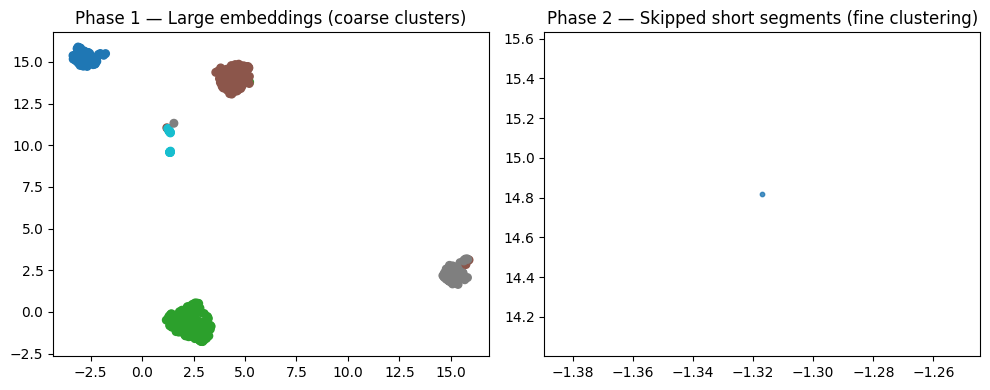

[NeMo W 2025-11-01 22:52:59 nemo_logging:361] C:\Users\Surface Studio\AppData\Local\Temp\ipykernel_18796\2374884170.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
      colors = plt.cm.get_cmap("tab10")
    


5124 18037 23066 200366
DER=0.2307 (Miss=0.0256, FA=0.0900, Conf=0.1151)


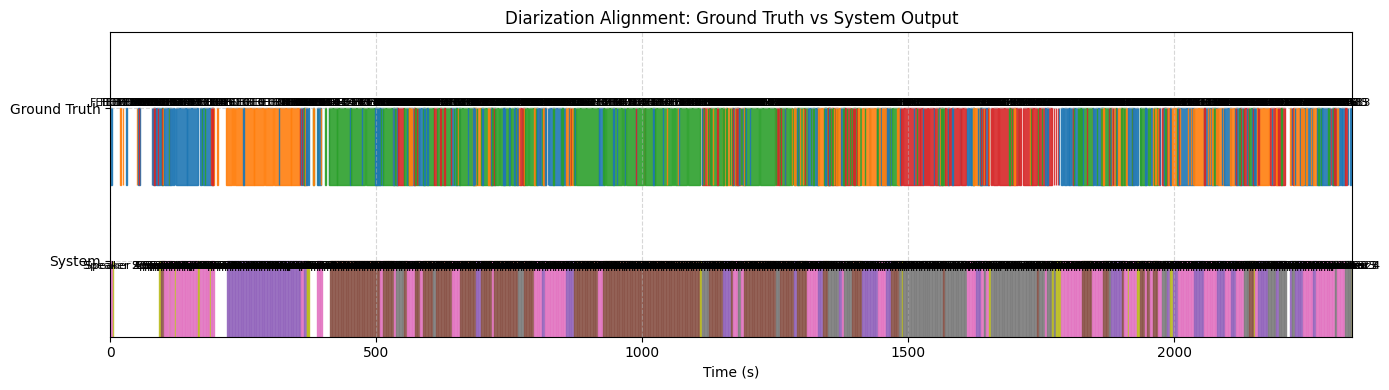

Quality=0.84 | MERGE:sys MEO015 covers {None, 'FEE013', 'MEO015', 'MEE014', 'FEE016'} | MERGE:sys MEE014 covers {None, 'FEE013', 'MEO015', 'MEE014', 'FEE016'} | MERGE:sys FEE013 covers {None, 'FEE013', 'MEO015', 'MEE014', 'FEE016'} | MERGE:sys UNMAPPED_SYS_Speaker 4 covers {None, 'FEE013', 'MEO015', 'MEE014', 'FEE016'} | MERGE:sys FEE016 covers {None, 'FEE013', 'MEO015', 'MEE014', 'FEE016'} | SPLIT:gt FEE013 split across {'FEE013', 'MEO015', 'MEE014', 'FEE016'} | SPLIT:gt FEE016 split across {'FEE013', 'MEO015', 'MEE014', 'FEE016'} | SPLIT:gt MEE014 split across {'FEE013', 'MEO015', 'MEE014', 'FEE016'} | SPLIT:gt MEO015 split across {'FEE013', 'MEO015', 'MEE014', 'FEE016'}
[{'start': 544, 'end': 87008, 'segments': [(544, 42464), (61472, 87008)]}, {'start': 1474080, 'end': 1483744, 'segments': [(1474080, 1483744)]}, {'start': 1525280, 'end': 2005280, 'segments': [(1525280, 1605088), (1617440, 1674720), (1705504, 1785088), (1785088, 1801696), (1805344, 1841120), (1868832, 1913824), (1928

Transcribing: 100%|██████████| 86/86 [28:56<00:00, 20.20s/it]


0.008524400347364323 0.030006754306286163 0.038373110541043226


In [ ]:
avg_miss = avg_fa = avg_conf = 0

for idx, row in enumerate(ds):
    # audio_path = row["audio"]["path"]   # local path in HF cache
    # full_path = os.path.join(base_dir, audio_path)
    if idx in [0, 1]:
        continue
    audio_bytes = row["audio"]["bytes"]
    waveform, sample_rate = torchaudio.load(io.BytesIO(audio_bytes))
    # resample if needed
    if sample_rate != 16000:
        waveform = torchaudio.functional.resample(waveform, sample_rate, 16000)
        sample_rate = 16000
    waveform = ensure_mono(waveform)
    num_samples = waveform.shape[-1]
    duration_sec = num_samples / sample_rate

    hours = int(duration_sec // 3600)
    minutes = int((duration_sec % 3600) // 60)
    seconds = int(duration_sec % 60)

    print(f"Audio duration: {hours:02d}:{minutes:02d}:{seconds:02d}")
    
    # speech_segments, labeled_segments, speaker_labels = diarization(waveform, sample_rate, vad_model, speaker_encoder, row)
    diar_map = diarization(waveform, sample_rate, vad_model, speaker_encoder, wavlm_model, row, use_cosine_norm=True, plot=True)
    speech_segments = diar_map["merged_segments"]
    speaker_labels = diar_map["labels"]
    # der_benchmark(speech_segments, sample_rate, speaker_labels, row)
    der, miss_rate, fa_rate, conf_rate = der_benchmark_full(speech_segments, sample_rate, speaker_labels, row)
    diag, summary = label_diagnostics(speech_segments, sample_rate, speaker_labels, row)
    # print(diag)
    print(summary)
    avg_miss += miss_rate
    avg_fa += fa_rate
    avg_conf += conf_rate

    chunks = chunk_by_silence_and_overlap(speech_segments, sample_rate, max_chunk=30, overlap=3)
    print(chunks)
    transcript = transcribe_chunks(waveform, sample_rate, chunks, asr_model)
    final_result = assign_speakers(transcript, speech_segments, sample_rate)
    diar_speech = process_timestamps(final_result, sample_rate)
    postprocess_diarization(client, diar_speech)
    # break  # demo with first sample
    # if idx > 4:
    break
data_size = idx + 1
print(avg_miss / data_size, avg_fa /data_size, avg_conf/data_size)

11763 7093 64871 147708
DER=0.5668 (Miss=0.0796, FA=0.0480, Conf=0.4392)
Quality=0.48 
0.07963685108457226 0.048020418663850296 0.43918406585966907

13089 8272 56555 147708
DER=0.5275 (Miss=0.0886, FA=0.0560, Conf=0.3829)
Quality=0.53 
0.08861402226013486 0.05600238308013107 0.38288379776315434

11904 7087 63885 147708
DER=0.5611 (Miss=0.0806, FA=0.0480, Conf=0.4325)
Quality=0.49
0.08059143715980177 0.047979797979797977 0.43250873344707125

0.13836967591488142 0.0457855937499998 0.32075445220632925

In [40]:
0.1242281178227053+0.09806041925006632+0.29922357330133875

0.5215121103741104

In [41]:
0.15035275887779345+0.0550184621859962+0.21968930646020884

0.4250605275239985

In [44]:
0.09648998247952342+0.08058672501130586+0.2482858411048024

0.42536254859563166

In [18]:
diag.keys()

dict_keys(['mapping', 'quality', 'issues', 'frame_errors'])

In [42]:
# diag["frame_errors"]
for err in diag["frame_errors"]:
    if err["gt"] != err["sys"]:
        if err["end_time"] - err["start_time"] >= 0.5:
            print(f'{(err["end_time"] - err["start_time"]):.02f}s ', end=",")

NameError: name 'diag' is not defined

In [40]:
print(avg_miss / data_size, avg_fa /data_size, avg_conf/data_size)

0.08444181491710331 0.037717099409831256 0.10283374739604609
